In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('canteen_rush_1000.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
print(df.head())

        Date  Time  Day  Lunch_Time Weather  Students Rush_Level
0 2026-03-11    14  Wed           0  Cloudy        21        Low
1 2026-03-24    14  Tue           0  Cloudy        20        Low
2 2026-03-01    12  Sun           1  Cloudy        85       High
3 2026-02-15    12  Sun           1  Cloudy        94       High
4 2026-03-15    13  Sun           1   Rainy        50     Medium


In [3]:
df.isnull()
df.isnull().sum()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1000 non-null   datetime64[ns]
 1   Time        1000 non-null   int64         
 2   Day         1000 non-null   object        
 3   Lunch_Time  1000 non-null   int64         
 4   Weather     1000 non-null   object        
 5   Students    1000 non-null   int64         
 6   Rush_Level  1000 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 54.8+ KB


,Date,Time,Lunch_Time,Students
count,1000,1000.000000,1000.000000,1000.000000
mean,2026-03-02 13:58:04.800000256,10.999000,0.411000,39.373000
min,2026-02-01 00:00:00,8.000000,0.000000,10.000000
25%,2026-02-16 00:00:00,9.000000,0.000000,18.000000
50%,2026-03-03 00:00:00,11.000000,0.000000,26.000000
75%,2026-03-17 00:00:00,13.000000,1.000000,61.000000
max,2026-03-31 00:00:00,14.000000,1.000000,99.000000
std,NaN,2.031533,0.492261,26.721226


<h3 style="color:skyblue">Target Distribution</h3>

This graph shows how many samples belong to each Rush Level.

If one category is much larger than others → dataset is imbalanced.

Balanced data helps model learn better.

In [4]:
df['Rush_Level'].value_counts()

Rush_Level
Low       599
Medium    208
High      193
Name: count, dtype: int64

If High rush appears most → canteen is busy frequently.

If Low rush dominates → model may predict Low more often.

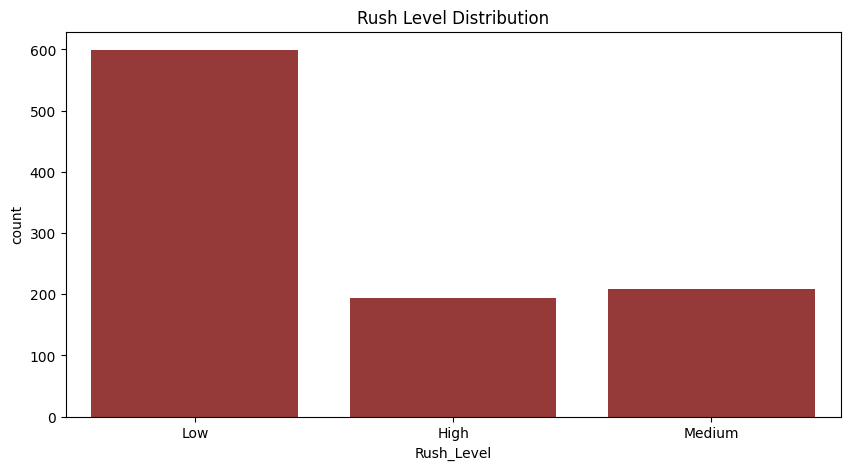

In [5]:
plt.figure(figsize=(10,5))
sns.countplot(x='Rush_Level', data=df,color='brown')
plt.title("Rush Level Distribution")
plt.show()

<h3 style="color:skyblue">Students vs Rush_Level</h3>

Shows relationship between number of students and rush level.

Boxplot helps see distribution and spread.

High rush → Higher number of students.

Low rush → Fewer students.

Students is likely the most important feature.

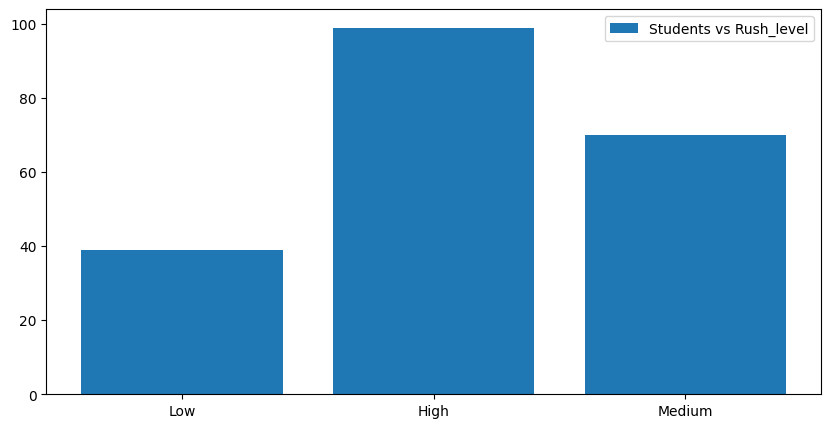

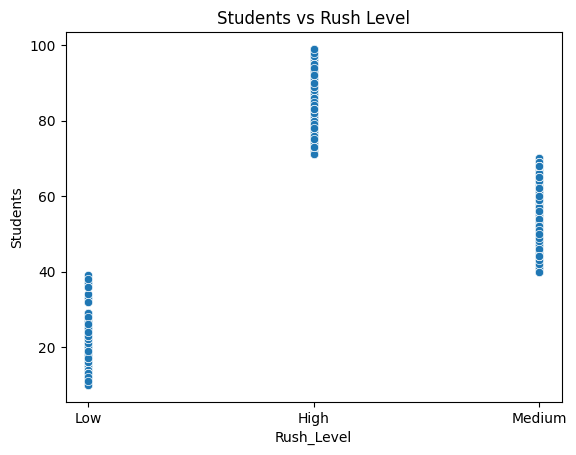

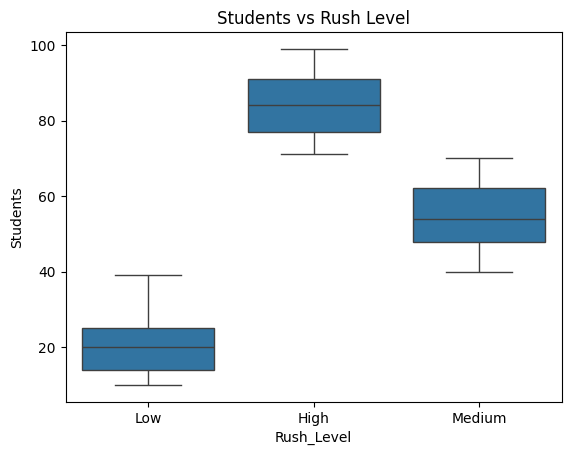

In [6]:
plt.figure(figsize=(10,5))
plt.bar( df['Rush_Level'],
        df['Students'],
        label='Students vs Rush_level')
plt.legend()
plt.show()

sns.scatterplot(x='Rush_Level', y='Students', data=df)
plt.title("Students vs Rush Level")
plt.show()

sns.boxplot(x='Rush_Level', y='Students', data=df)
plt.title("Students vs Rush Level")
plt.show()

<h3 style="color:skyblue">Time vs Rush_Level</h3>

Shows how rush changes with time.

Helps detect peak hours.

In [7]:
df['Time'].value_counts()

Time
13    149
10    149
8     148
14    147
9     145
12    143
11    119
Name: count, dtype: int64

Rush likely highest at 12–1 PM.

After lunch time, rush decreases.

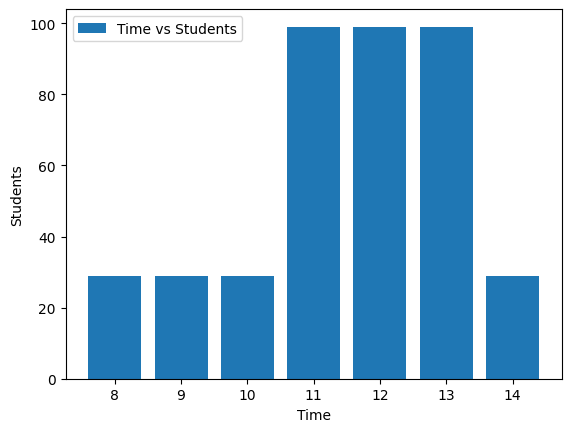

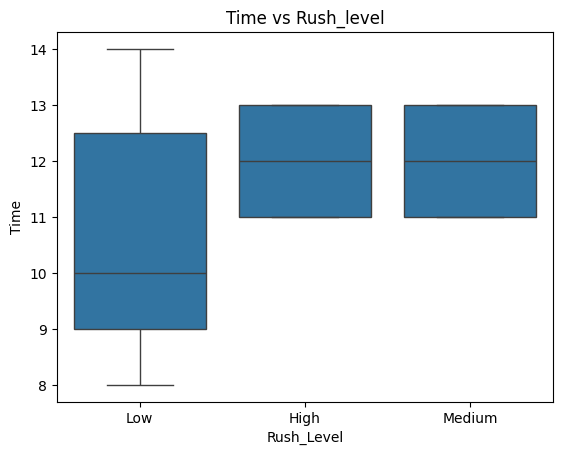

In [8]:
plt.bar(df['Time'],df['Students'],label = 'Time vs Students')
plt.xlabel('Time')
plt.ylabel('Students')
plt.legend()
plt.show()

sns.boxplot(x='Rush_Level',
            y='Time',
            data=df)
plt.title("Time vs Rush_level")
plt.show()

<h3 style="color:skyblue">Lunch_Time vs Rush_Level</h3>

Shows whether lunch time affects rush.

Lunch_Time = 1 means active lunch period.

In [9]:
df['Lunch_Time'].value_counts()

Lunch_Time
0    589
1    411
Name: count, dtype: int64

Most High rush happens when Lunch_Time = 1.

Lunch_Time strongly influences rush level.

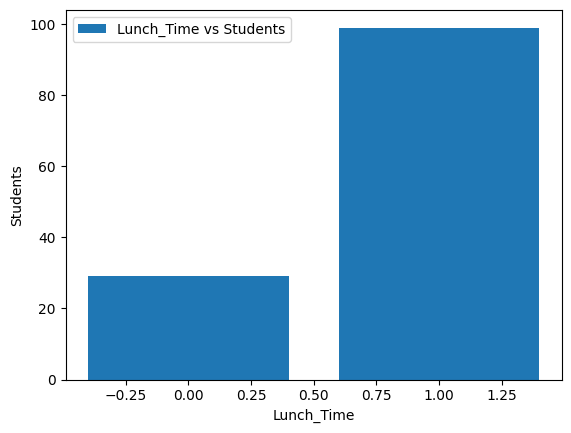

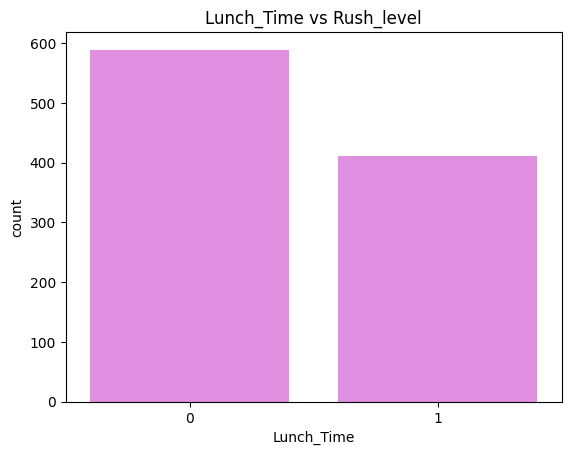

In [10]:
plt.bar(df['Lunch_Time'],df['Students'],label='Lunch_Time vs Students')
plt.xlabel('Lunch_Time')
plt.ylabel('Students')
plt.legend()
plt.show()

sns.countplot(x='Lunch_Time',
            data=df,
            color='violet')
plt.title("Lunch_Time vs Rush_level")
plt.show()

<h3 style="color:skyblue">Weather vs Rush_Level</h3>

Shows effect of weather on rush.

Helps understand external factors.

In [11]:
df['Weather'].value_counts()

Weather
Sunny     578
Rainy     225
Cloudy    197
Name: count, dtype: int64

Rainy weather may reduce rush.

Cloudy or normal weather may increase rush.

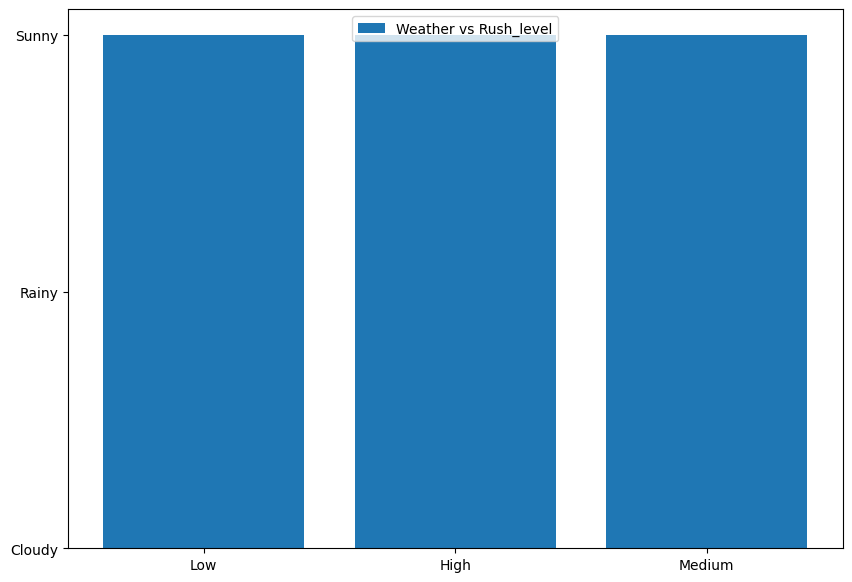

C:\Users\wasim\AppData\Local\Temp\ipykernel_7428\3789484615.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:yellow'` for the same effect.

  sns.countplot(x='Weather',


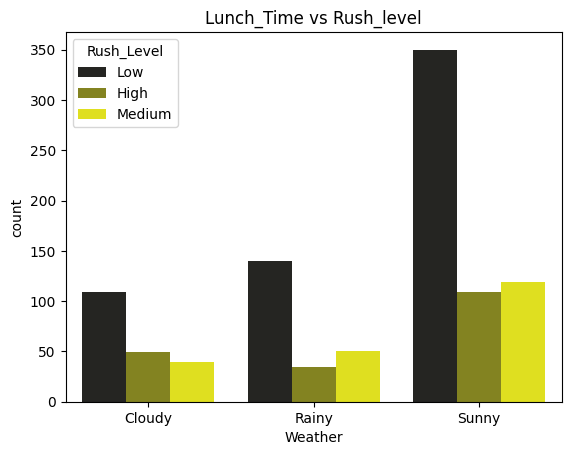

In [12]:
plt.figure(figsize=(10,7))
plt.bar(
        df['Rush_Level'],
        df['Weather'],
        label='Weather vs Rush_level')
plt.legend()
plt.show()

sns.countplot(x='Weather',
              hue='Rush_Level',
            data=df,
            color='yellow')
plt.title("Lunch_Time vs Rush_level")
plt.show()

<h3 style="color:skyblue">Day vs Rush_Level</h3>

Shows rush pattern across days of the week.

Helps detect busy weekdays.

In [13]:
df['Day'].value_counts()

Day
Mon    171
Thu    156
Tue    142
Sat    141
Sun    140
Wed    135
Fri    115
Name: count, dtype: int64

Some days (like Monday) may have more High rush.

Weekday pattern affects crowd behavior.

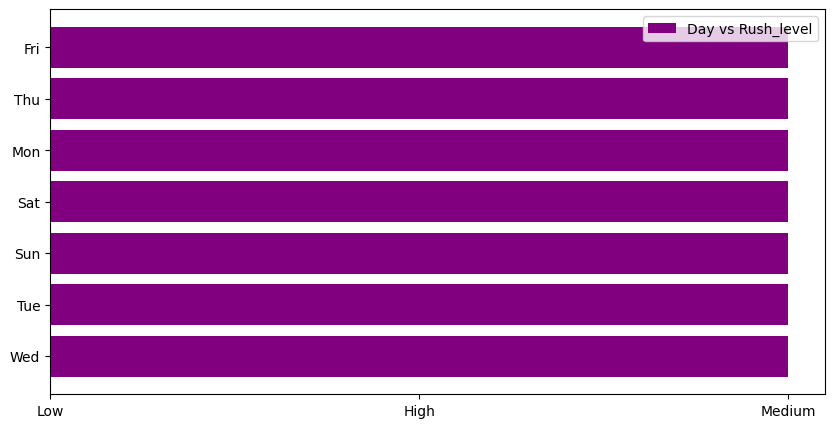

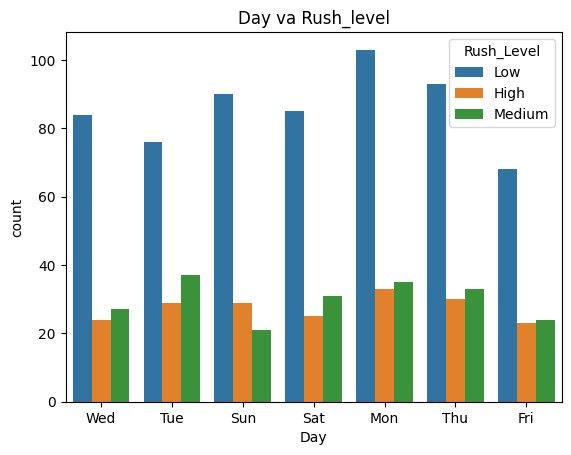

In [14]:
plt.figure(figsize=(10,5))
plt.barh(df['Day'],
    df['Rush_Level'],       
        color='purple',
        label='Day vs Rush_level')
plt.legend()
plt.show()

sns.countplot(x = 'Day',
              hue='Rush_Level',
              data=df)
plt.title("Day va Rush_level")
plt.show()

<h3 style="color:skyblue">Month vs Rush_Level</h3>

Shows seasonal trend.

Helps detect monthly variation.

Certain months may have higher rush.

Exam or special periods may influence rush.

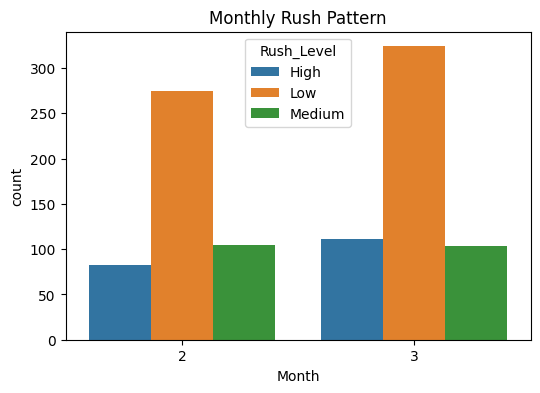

In [15]:
df['Month'] = df['Date'].dt.month

plt.figure(figsize=(6,4))
sns.countplot(x='Month', hue='Rush_Level', data=df)
plt.title("Monthly Rush Pattern")
plt.show()

In [16]:
# 📊 What is Correlation?

# Correlation means:

# 🔗 “How strongly two variables are related”

# It tells:

# If one increases, does the other increase?

# If one increases, does the other decrease?

# Or are they unrelated?

# 📈 Correlation Values Range

# Correlation value is between -1 and +1

# Value	Meaning
# +1	Perfect positive relationship
# 0	No relationship
# -1	Perfect negative relationship
# 🔵 Positive Correlation (+)

# If Students increase → Rush increases

# Example:

# Students ↑  →  Rush ↑
# 🔴 Negative Correlation (-)

# If Students increase → Rush decreases

# Example:

# Students ↑  →  Rush ↓
# ⚪ Zero Correlation

# No relationship.

# 🧊 What is a Heatmap?

# A Heatmap is just a colored table.

# Dark red = Strong positive

# Dark blue = Strong negative

# Light color = Weak relation

# 🔎 How to Read It (Very Important)

# Imagine you see this:

# 	Students	Lunch_Time	Rush
# Students	1.00	0.10	0.85
# Lunch_Time	0.10	1.00	0.65
# Rush	0.85	0.65	1.00

# Now understand:

# 🟢 Students vs Rush = 0.85

# ✔ Strong positive relationship
# ✔ More students → Higher rush

# This is very important feature 🔥

# 🟡 Lunch_Time vs Rush = 0.65

# ✔ Moderate positive relationship
# ✔ During lunch → Rush increases

# ⚪ Time vs Rush = 0.05

# ✖ Very weak
# ✖ Time alone may not matter much

# 🧠 Why Diagonal Is Always 1?

# Because:

# Students vs Students = 100% related

# Time vs Time = 100% related

# So always 1.

<h3 style="color:skyblue">Correlation</h3>

Shows strength of relationship between numeric features.

Values range from -1 to +1.

Red → strong positive relation.

Blue → strong negative relation.

Students strongly correlated with Rush.

Lunch_Time moderately correlated.

Month weakly correlated.

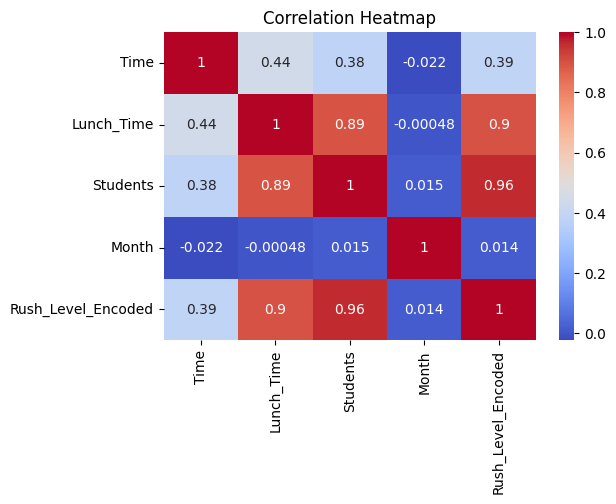

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Encode only target
rush_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Rush_Level_Encoded'] = df['Rush_Level'].map(rush_mapping)
# df['Rush_Level_Encoded'] = le.fit_transform(df['Rush_Level'])

# Select ONLY numeric columns
numeric_df = df[['Time',
                 'Lunch_Time',
                 'Students',
                 'Month',
                 'Rush_Level_Encoded']]

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Target correlations

Students → Rush_Level_Encoded = 0.96 ✅

Very strong positive correlation. Intuition matches reality: more students → higher rush.

Lunch_Time → Rush_Level_Encoded = 0.90

High correlation — rush is heavily concentrated around lunch hours.

Time → Rush_Level_Encoded = 0.39

Moderate correlation — time of day matters, but not as strongly as lunch period.

Month → Rush_Level_Encoded = 0.014

Almost zero — seasonal effect is negligible.

In [18]:
# le.classes_

<h3 style="color:skyblue">Data preprocessing</h3>

<h4 style="color:">One-hot Encoding</h4>

In [19]:
df=pd.get_dummies(df,columns=['Weather','Day'],drop_first=True)

In [20]:
df.head()

,Date,Time,Lunch_Time,Students,Rush_Level,Month,Rush_Level_Encoded,Weather_Rainy,Weather_Sunny,Day_Mon,Day_Sat,Day_Sun,Day_Thu,Day_Tue,Day_Wed
0,2026-03-11,14,0,21,Low,3,0,False,False,False,False,False,False,False,True
1,2026-03-24,14,0,20,Low,3,0,False,False,False,False,False,False,True,False
2,2026-03-01,12,1,85,High,3,2,False,False,False,False,True,False,False,False
3,2026-02-15,12,1,94,High,2,2,False,False,False,False,True,False,False,False
4,2026-03-15,13,1,50,Medium,3,1,True,False,False,False,True,False,False,False


In [21]:
X = df.drop(['Rush_Level','Rush_Level_Encoded','Date'],axis=1)
y = df['Rush_Level_Encoded']

In [22]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,
                                                 y,
                                                 test_size=0.2,
                                                 random_state=42,
                                                 stratify=y)
#stratify=y ensures train/test sets keep the same rush-level distribution.

In [23]:
#Scale features for models like KNN
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

<h3 style="color:skyblue">Linear Regression</h3>

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

# Train Linear Regression model
linearR = LinearRegression()
linearR.fit(X_train_scaled, y_train)

# Predict values
y_pred_lin = linearR.predict(X_test_scaled)


In [25]:
# Convert predictions to nearest class (0,1,2)
# convert predictions into class labels.
# Example:
# 0.2 → 0
# 1.3 → 1
# 1.8 → 2
# 0.9 → 1
# Result:
# [0,1,2,1]
y_pred_lin_class = np.round(y_pred_lin).astype(int)
# ensures predictions stay between 0 and 2.
# Example:
# Before clipping:
# [-1, 0, 1, 2, 3]
# After clipping:
# [0, 0, 1, 2, 2]
# Why?
# Because valid rush levels are only:
# 0 = Low
# 1 = Medium
# 2 = High
y_pred_lin_class = np.clip(y_pred_lin_class, 0, 2)


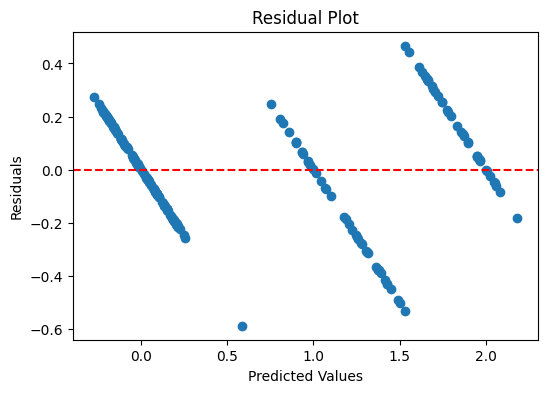

In [26]:

# -------------------------------
# Residual Calculation
# -------------------------------
residuals = y_test - y_pred_lin

# -------------------------------
# Residual Plot:Residual shows how wrong the prediction is.
# plots:
# X-axis → Predicted values
# Y-axis → Residuals
# -------------------------------
plt.figure(figsize=(6,4))
plt.scatter(y_pred_lin, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

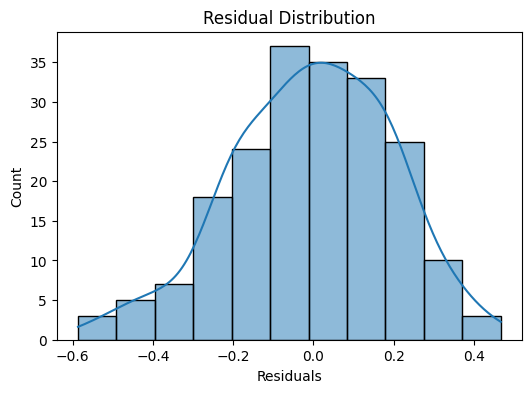

In [27]:


# -------------------------------
# Residual Distribution
# Good case:
# Bell-shaped curve.
# Why?
# Because Linear Regression assumes normal error distribution.
# -------------------------------
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()


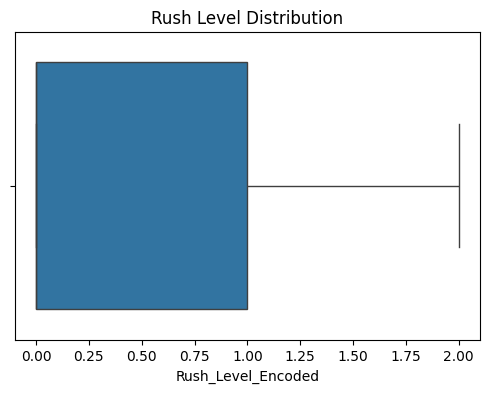

In [28]:
# Boxplot (Target Distribution)
# Shows distribution of rush levels.
# Example data:
# 0,0,0,1,1,1,2,2
# Boxplot shows:
# median
# spread
# outliers
# -------------------------------
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Rush_Level_Encoded'])
plt.title("Rush Level Distribution")
plt.show()

In [29]:
# -------------------------------
# Metrics
# -------------------------------
mse = mean_squared_error(y_test, y_pred_lin)
# Lower MSE → better model.
r2 = r2_score(y_test, y_pred_lin)
# R² tells how much variation the model explains.
accuracy = accuracy_score(y_test, y_pred_lin_class)

print("R2 Score:", r2)
print("Linear Regression MSE:", mse)
print("Accuracy after rounding:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lin_class))
# Precision
# How accurate predicted class is

# Recall
# How many real cases were detected

# F1-score
# Balance of precision and recall

R2 Score: 0.9358909712277111
Linear Regression MSE: 0.039869404993486415
Accuracy after rounding: 0.985

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       120
           1       0.98      0.95      0.96        42
           2       0.95      1.00      0.97        38

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.99      0.98      0.99       200



The Linear Regression model performed very well on the canteen rush prediction dataset.

The R² score of 0.93 indicates that the model explains most of the variance in rush levels.

The Mean Squared Error is 0.039, showing very low prediction error.

After converting predictions into classes, the model achieved 98.5% accuracy, indicating highly reliable predictions for low, medium, and high rush levels.

<h3 style="color:skyblue">Logistic Regression</h3>

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix,
                             mean_squared_error,
                               adjusted_rand_score)
logistic = LogisticRegression(max_iter=1000)
logistic.fit(X_train_scaled,y_train)
train_predict_log = logistic.predict(X_train_scaled)
test_predict_log = logistic.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train,train_predict_log)
test_accuracy = accuracy_score(y_test,test_predict_log)

cr_logistic = classification_report(y_test,test_predict_log)
cm_logistic = confusion_matrix(y_test,test_predict_log)

print("Train Accuracy : ",train_accuracy)
print("Test Accuracy : ",test_accuracy)
print("\nConfusion Metrics: \n",cm_logistic)
print("\nClassification Report : \n",cr_logistic)


Train Accuracy :  0.99125
Test Accuracy :  0.965

Confusion Metrics: 
 [[119   1   0]
 [  0  37   5]
 [  0   1  37]]

Classification Report : 
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       120
           1       0.95      0.88      0.91        42
           2       0.88      0.97      0.93        38

    accuracy                           0.96       200
   macro avg       0.94      0.95      0.94       200
weighted avg       0.97      0.96      0.97       200



<h3 style="color:skyblue">Decision Tree</h3>

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
decisionC = DecisionTreeClassifier(max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42)
decisionC.fit(X_train,y_train)

y_proba_dec = decisionC.predict_proba(X_test)

y_train_pred_dec = decisionC.predict(X_train)
y_test_pred_dec = decisionC.predict(X_test)

train_accu_dec = accuracy_score(y_train,y_train_pred_dec)
test_accu_dec = accuracy_score(y_test,y_test_pred_dec)
cm_dec = confusion_matrix(y_test,y_test_pred_dec)
cr_dec = classification_report(y_test,y_test_pred_dec)
roc_dec = roc_auc_score(y_test,y_proba_dec,multi_class='ovr')

print("Train accuracy : ",train_accu_dec)
print("Test accuracy : ",test_accu_dec)
print("\nConfusion metrics : \n",cm_dec)
print("\nClassification Report : \n",cr_dec)
print("Roc_AUC score : ",roc_dec)



Train accuracy :  1.0
Test accuracy :  1.0

Confusion metrics : 
 [[120   0   0]
 [  0  42   0]
 [  0   0  38]]

Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       120
           1       1.00      1.00      1.00        42
           2       1.00      1.00      1.00        38

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Roc_AUC score :  1.0


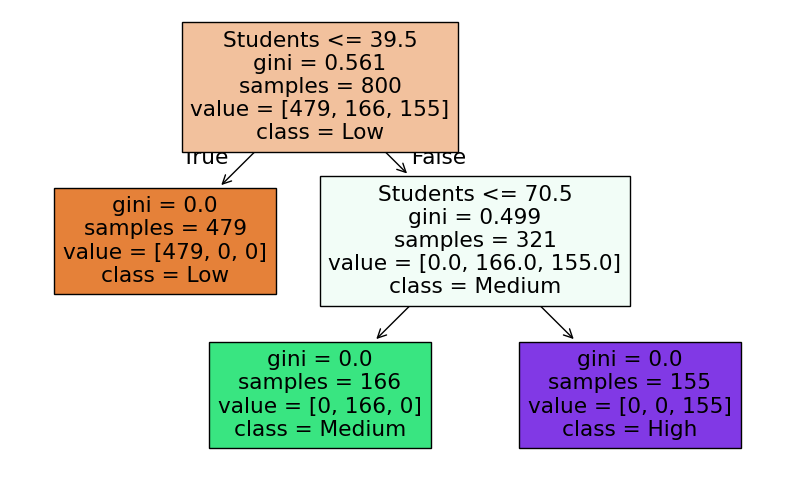

In [32]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10,6))
plot_tree(decisionC, 
          filled=True,
          feature_names=X.columns,
          class_names=['Low','Medium','High']
          )
plt.show()

In [39]:
importance = pd.Series(decisionC.feature_importances_,
                       index=X.columns)

print(importance.sort_values(ascending=False))

Students         1.0
Time             0.0
Lunch_Time       0.0
Month            0.0
Weather_Rainy    0.0
Weather_Sunny    0.0
Day_Mon          0.0
Day_Sat          0.0
Day_Sun          0.0
Day_Thu          0.0
Day_Tue          0.0
Day_Wed          0.0
dtype: float64


<h3 style="color:skyblue">Random Forest</h3>

In [63]:
from sklearn.ensemble import RandomForestClassifier

# n_estimators: Number of trees in the forest
# max_depth: Maximum depth of each tree
# random_state: Ensures reproducibility
randomForest = RandomForestClassifier(n_estimators=100,
                                      max_depth=7,
                                      random_state=42)
randomForest.fit(X_train,y_train)

y_proba_rf = randomForest.predict_proba(X_test)

y_train_pred_rf = randomForest.predict(X_train)
y_test_pred_rf = randomForest.predict(X_test)

train_accu_rf = accuracy_score(y_train,y_train_pred_rf)
test_accu_rf = accuracy_score(y_test,y_test_pred_rf)
cm_rf = confusion_matrix(y_test,y_test_pred_rf)
cr_rf = classification_report(y_test,y_test_pred_rf)
roc_rf = roc_auc_score(y_test,y_proba_rf,multi_class='ovr')

print("Train accuracy : ",train_accu_rf)
print("Test accuracy : ",test_accu_rf)
print("\nConfusion metrics : \n",cm_rf)
print("\nClassification Report : \n",cr_rf)
print("Roc_AUC score : ",roc_rf)



Train accuracy :  1.0
Test accuracy :  1.0

Confusion metrics : 
 [[119   0   0]
 [  0  45   0]
 [  0   0  36]]

Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       119
           1       1.00      1.00      1.00        45
           2       1.00      1.00      1.00        36

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Roc_AUC score :  1.0


In [51]:
# ImportanceRF = randomForest.feature_importances_
# print(ImportanceRF)
ImportanceRF = pd.Series(randomForest.feature_importances_,
                       index=X.columns)

print(ImportanceRF.sort_values(ascending=False))

Students         0.593919
Lunch_Time       0.272510
Time             0.110487
Month            0.006005
Weather_Rainy    0.003766
Weather_Sunny    0.003119
Day_Sun          0.002272
Day_Tue          0.001805
Day_Sat          0.001700
Day_Thu          0.001527
Day_Mon          0.001508
Day_Wed          0.001383
dtype: float64


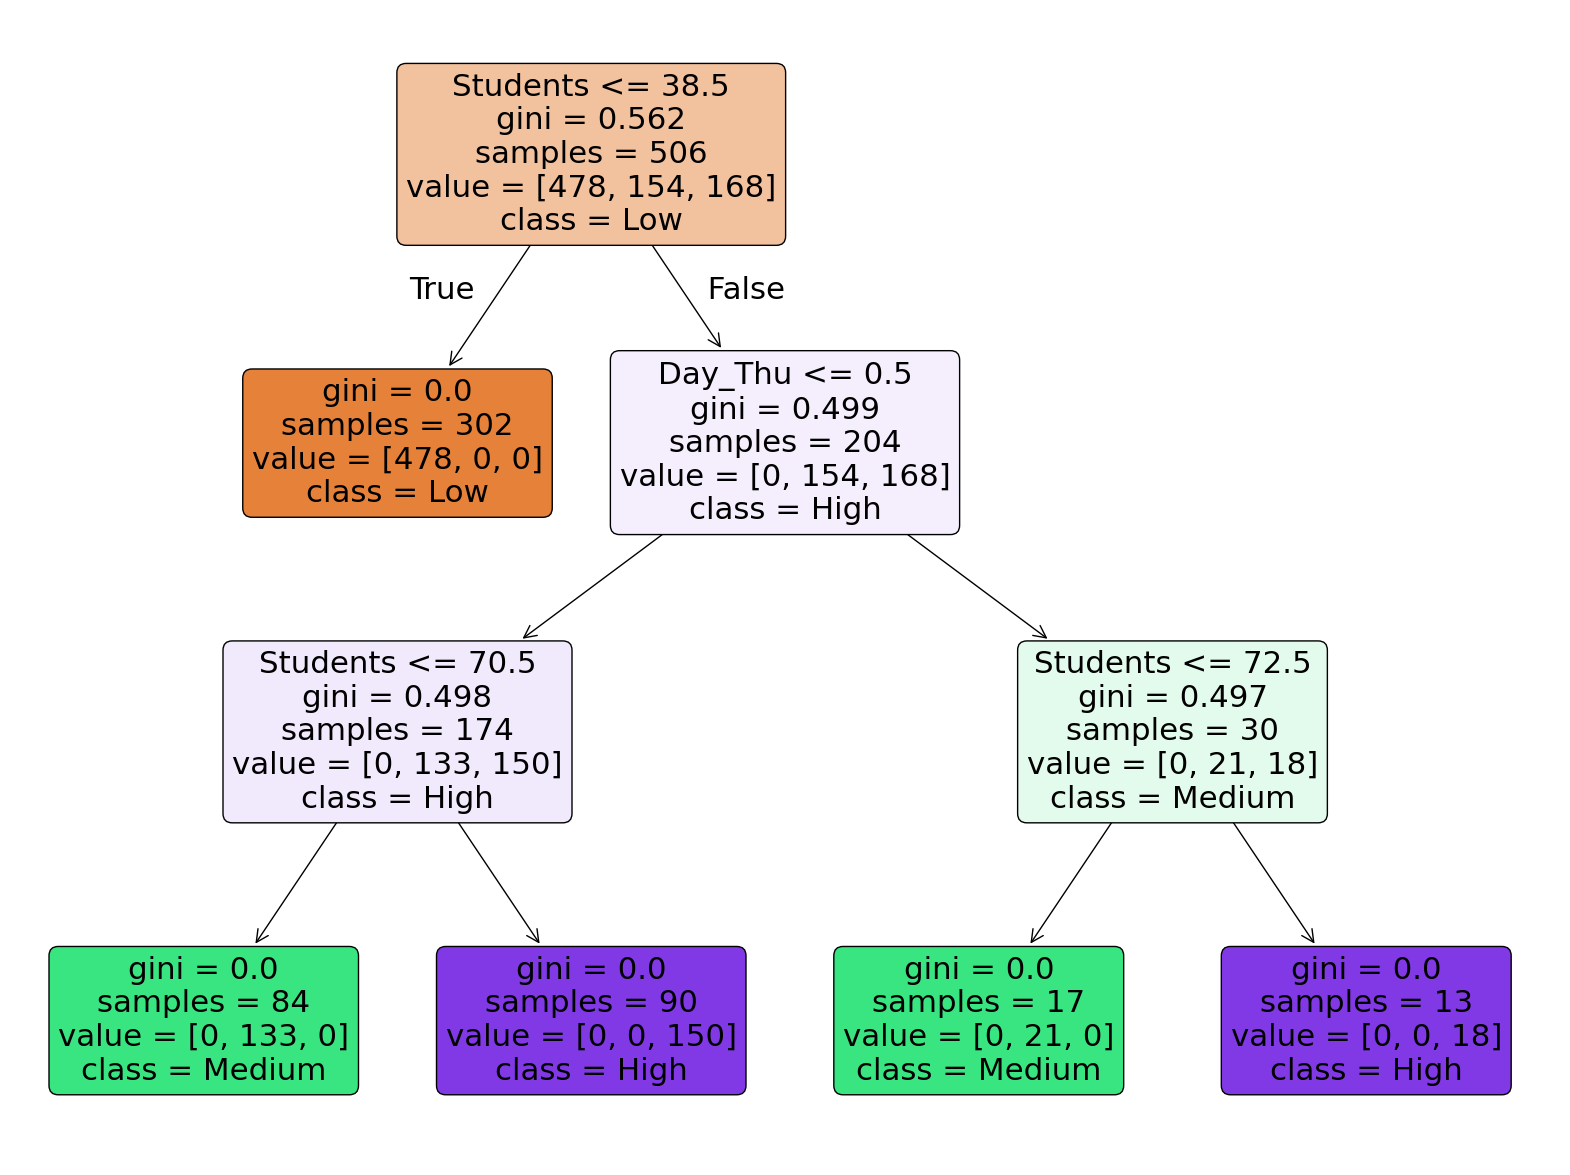

In [61]:
from sklearn.tree import plot_tree

#randomForest.estimators_ is a list of all trees in the forest.
# Pick the first tree from the Random Forest
one_tree = randomForest.estimators_[0]

plt.figure(figsize=(20,15))
plot_tree(
    one_tree,
    filled=True,
    feature_names=X.columns,
    class_names=['Low', 'Medium', 'High'],
    rounded=True
)
plt.show()

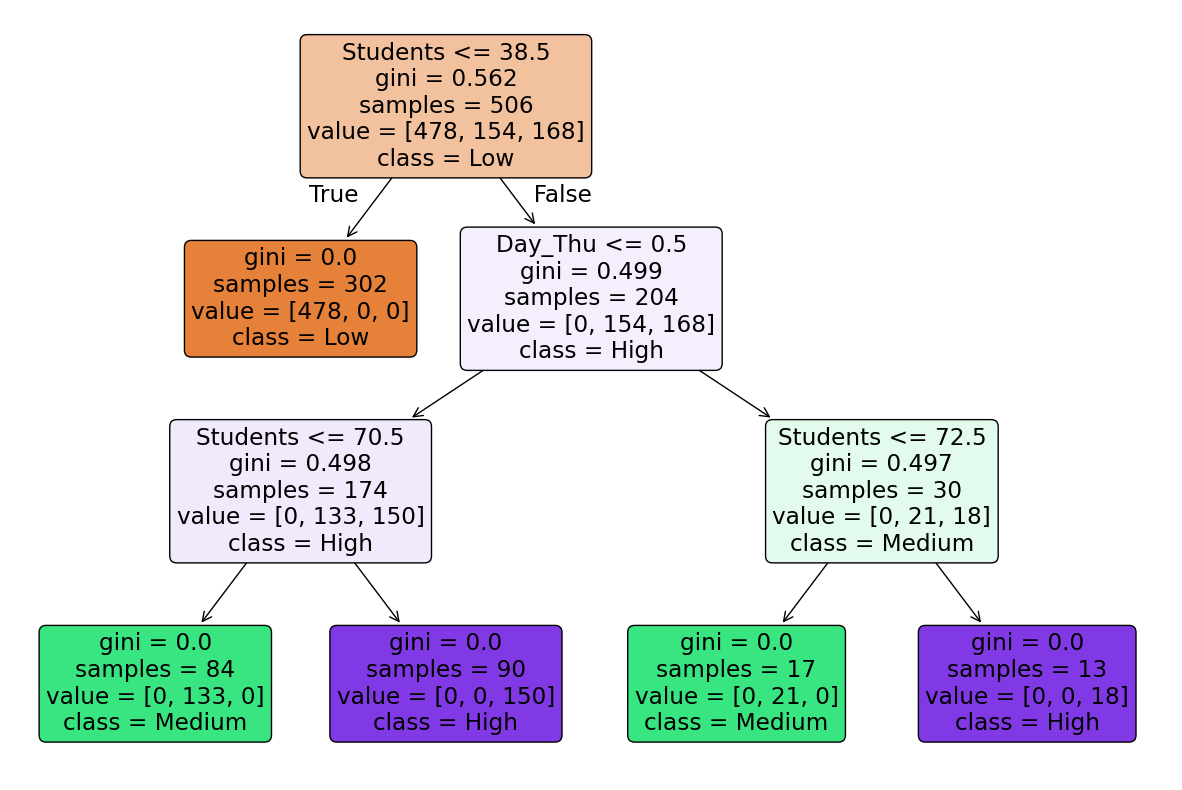

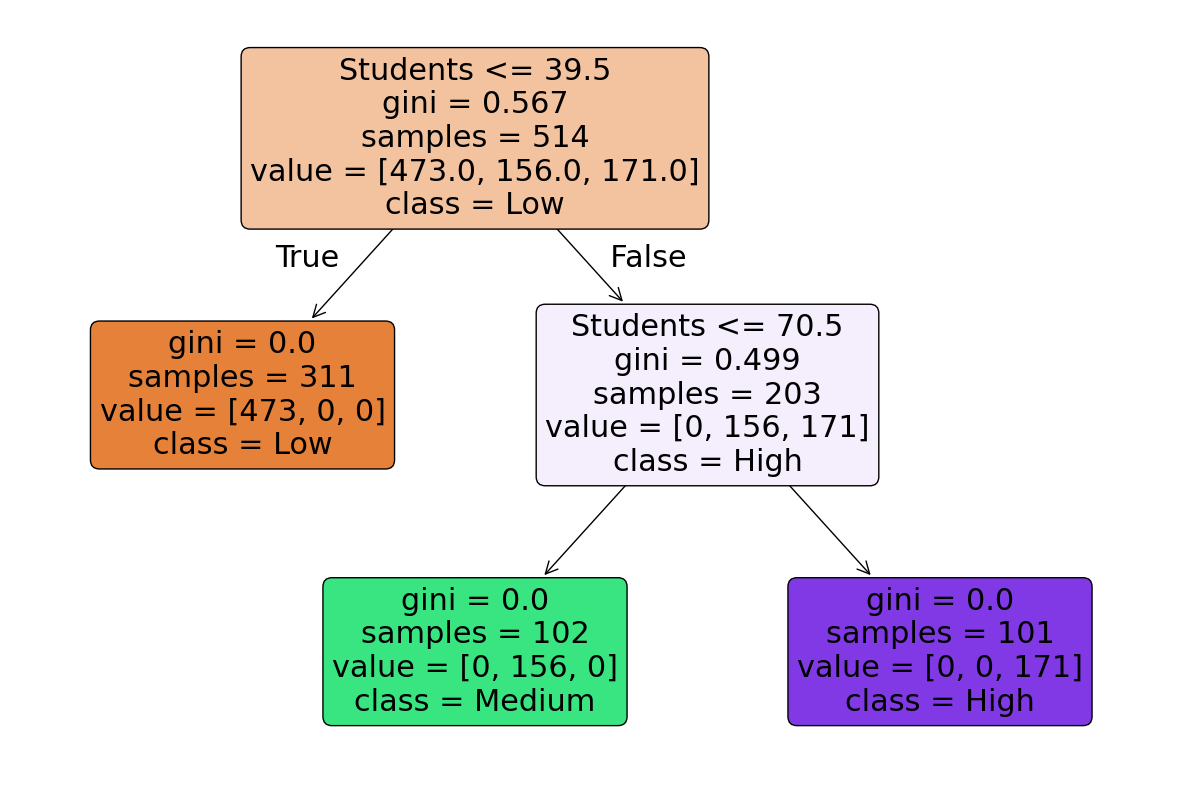

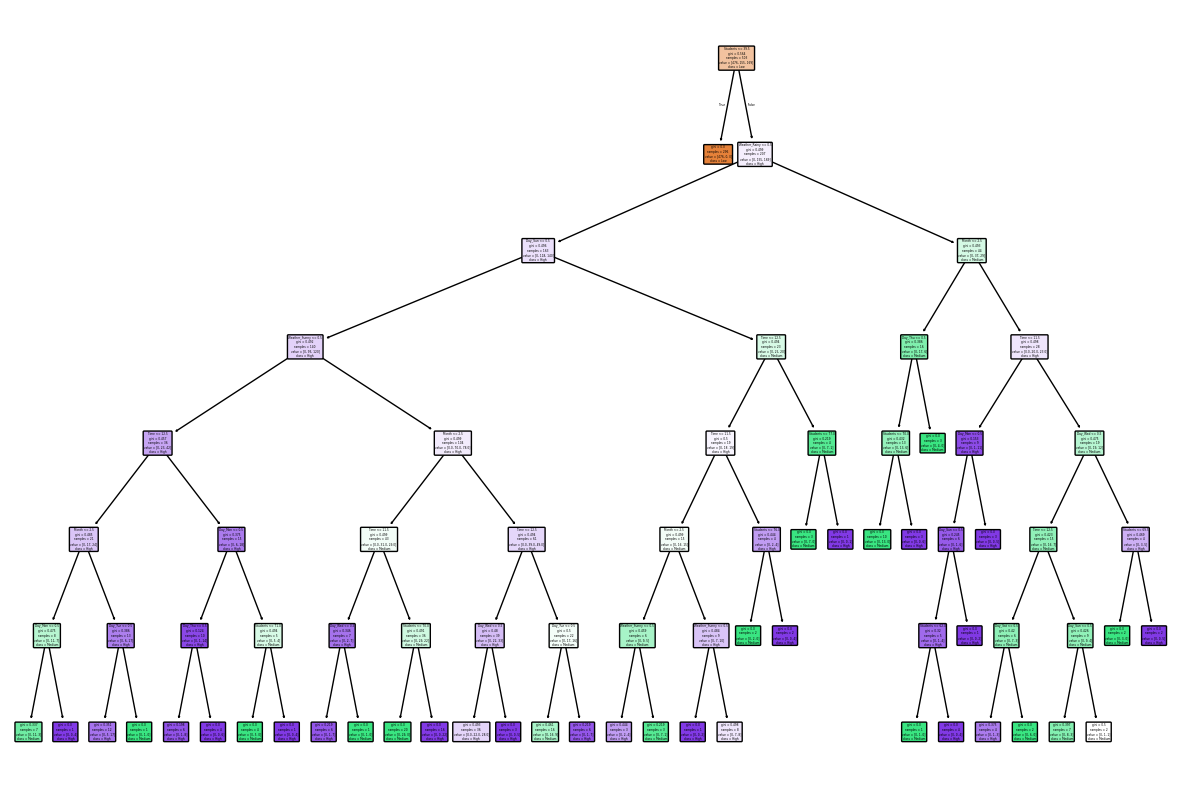

In [62]:
for i in range(3):  # visualize first 3 trees
    plt.figure(figsize=(15,10))
    plot_tree(randomForest.estimators_[i], filled=True, feature_names=X.columns,
              class_names=['Low','Medium','High'], rounded=True)
    plt.show()

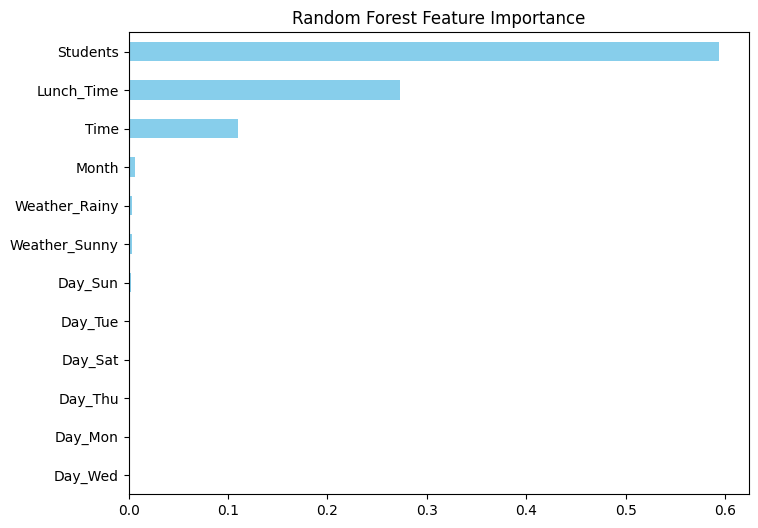

In [64]:
ImportanceRF.sort_values().plot(kind='barh', figsize=(8,6), color='skyblue')
plt.title('Random Forest Feature Importance')
plt.show()

<h3 style="color:skyblue">KNeighborsClassifier</h3>

In [34]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled,y_train)
train_predict_knn = knn.predict(X_train_scaled)
test_predict_knn = knn.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train,train_predict_knn)
test_accuracy = accuracy_score(y_test,test_predict_knn)

cr_knn = classification_report(y_test,test_predict_knn)
cm_knn = confusion_matrix(y_test,test_predict_knn)

print("Train Accuracy : ",train_accuracy)
print("Test Accuracy : ",test_accuracy)
print("\nConfusion Metrics: \n",cm_logistic)
print("\nClassification Report : \n",cr_logistic)


Train Accuracy :  0.94875
Test Accuracy :  0.905

Confusion Metrics: 
 [[119   1   0]
 [  0  37   5]
 [  0   1  37]]

Classification Report : 
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       120
           1       0.95      0.88      0.91        42
           2       0.88      0.97      0.93        38

    accuracy                           0.96       200
   macro avg       0.94      0.95      0.94       200
weighted avg       0.97      0.96      0.97       200



<h3 style="color:skyblue">K-Means Clustering</h3>

In [35]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_train_scaled)

# Map clusters to true labels using Adjusted Rand Index
y_kmeans_train = kmeans.labels_
ari_train = adjusted_rand_score(y_train, y_kmeans_train)

y_kmeans_test = kmeans.predict(X_test_scaled)
ari_test = adjusted_rand_score(y_test, y_kmeans_test)

print("\n=== K-Means Clustering ===")
print("Adjusted Rand Index (train):", ari_train)
print("Adjusted Rand Index (test):", ari_test)



=== K-Means Clustering ===
Adjusted Rand Index (train): 0.590138833105491
Adjusted Rand Index (test): 0.651254207454046


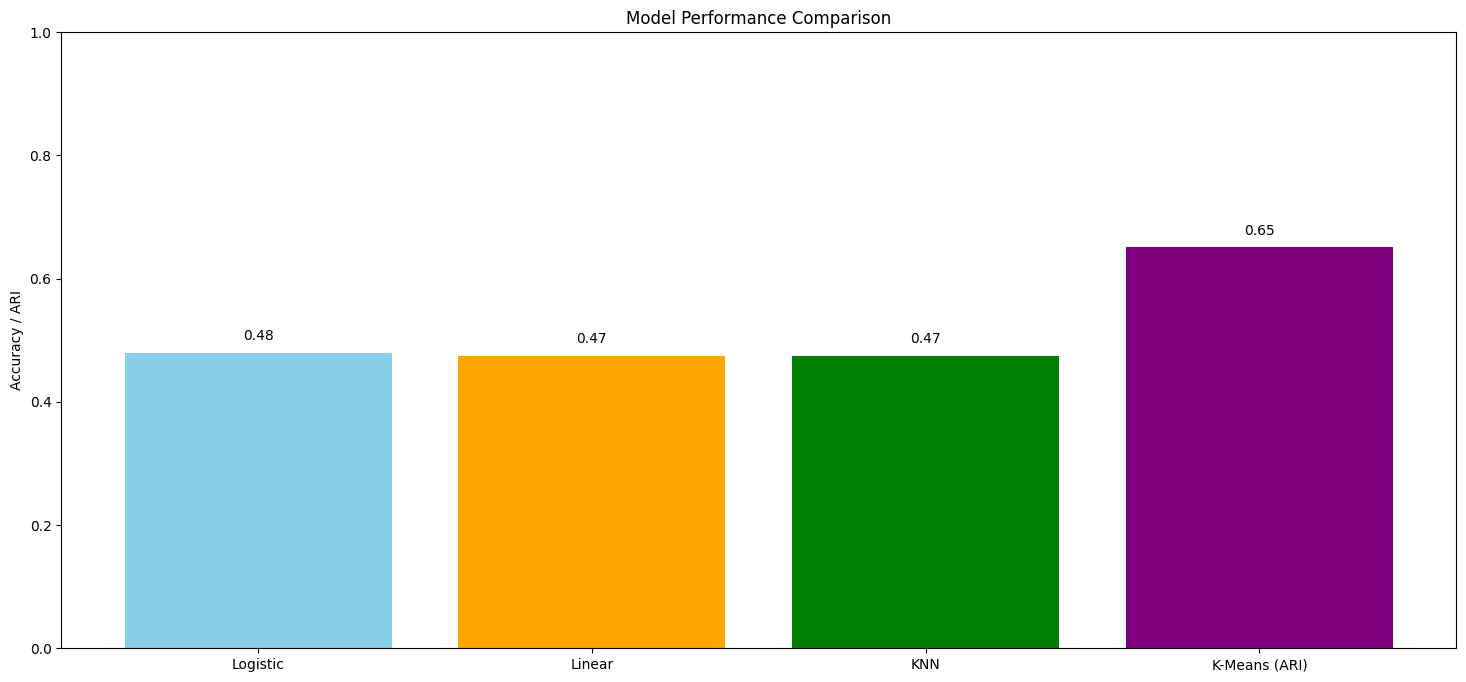

In [ ]:
models = ['Logistic', 'Linear', 'KNN', 'K-Means (ARI)']
scores = [
    accuracy_score(y_test, test_predict_log),
    accuracy_score(y_test, y_pred_lin_class),
    accuracy_score(y_test, test_predict_knn),
    ari_test
]

plt.figure(figsize=(18,8))
bars = plt.bar(models, scores, color=['skyblue','orange','green','purple'])
plt.ylim(0,1)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f"{bar.get_height():.2f}", ha='center')
plt.ylabel('Accuracy / ARI')
plt.title('Model Performance Comparison')
plt.show()